# Employee Attrition Prediction using Machine Learning

## Week 2 Internship Project

**Name:** Khushi Taneja

**Internship:** XYlofy AI

### Problem Statement
The objective of this project is to build a machine learning model that predicts whether an employee is likely to leave the company based on various employee-related factors such as job satisfaction, monthly income, work-life balance, years at the company, and performance rating.

### Business Objective
Employee attrition leads to increased hiring costs, training expenses, and reduced productivity. This project aims to help HR departments identify employees who are at risk of leaving so that proactive retention strategies can be implemented.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\ragha\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


## Task 1: Data Loading & Exploration

The dataset is loaded successfully. We begin by displaying the first 10 rows to understand the structure of the data and the available features.

In [7]:
print("Dataset Shape",df.shape)

print("Number of Rows",df.shape[0])
print("Number of Columns",df.shape[1])

Dataset Shape (1470, 35)
Number of Rows 1470
Number of Columns 35


In [8]:
#Display the dataset information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
# Display the coloumns names 
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


### Target Variable

The target column is **Attrition**.

- Yes → Employee Left
- No → Employee Stayed

In [10]:
# Count employees who left and stayed
attrition_counts = df['Attrition'].value_counts()

print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [ ]:
# Calculate attrition rate
attrition_rate = (df['Attrition'].value_counts(normalize = True)*100)
print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


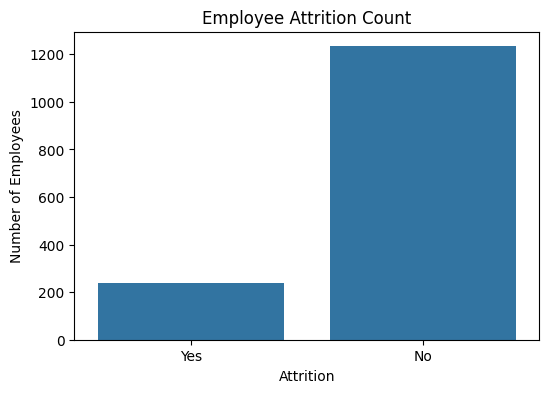

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='Attrition', data=df)

plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

In [13]:
# Numeric columns
numeric_columns = df.select_dtypes(include=['int64','float64']).columns

# Categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Number of Numeric Columns:", len(numeric_columns))
print("Number of Categorical Columns:", len(categorical_columns))

print("\nNumeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)


Number of Numeric Columns: 26
Number of Categorical Columns: 9

Numeric Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Categorical Columns:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


### Observation

The dataset contains more employees who stayed than employees who left. This indicates that the target variable is **imbalanced**, meaning the number of employees who left the company is significantly lower than those who stayed. During model building, class imbalance should be handled to improve prediction performance.

## Task 2: Data Cleaning & Preprocessing

In this section, we prepare the dataset for machine learning by checking for missing values, removing unnecessary columns, encoding categorical variables, and scaling numerical features.

In [43]:
df = pd.read_csv(r"C:\Users\ragha\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv")
# Display first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [45]:
# Check missing values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [46]:
# Total missing values
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


### Observation

The dataset contains no missing values. Therefore, no missing value treatment is required.

In [47]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [48]:
# Drop unnecessary columns

df.drop(
    columns=[
        'EmployeeNumber',
        'Over18',
        'StandardHours',
        'EmployeeCount'
    ],
    inplace=True
)

print("Columns dropped successfully.")

Columns dropped successfully.


In [50]:
# Convert Attrition column

df["Attrition"] = df["Attrition"].replace({
    "Yes": 1,
    "No": 0
})

In [51]:
print(df["Attrition"].unique())

[1 0]


In [52]:
# Separate features and target variable

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1470, 30)
Target Shape: (1470,)


In [53]:
# Identify categorical columns

categorical_columns = X.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [54]:
# One-Hot Encode categorical variables

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape after Encoding:", X.shape)

Shape after Encoding: (1470, 44)


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1176, 44)
Testing Set: (294, 44)


In [57]:
numeric_columns = X_train.select_dtypes(include=["int64", "float64"]).columns

print(numeric_columns)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])

X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

print("Scaling completed successfully.")

Scaling completed successfully.


## Task 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset, identify patterns, and discover relationships between employee characteristics and attrition.

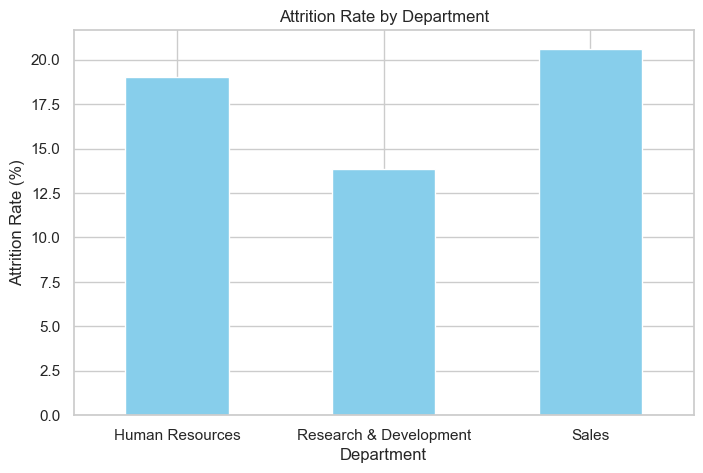

In [71]:
plt.figure(figsize=(8,5))

department_attrition = pd.crosstab(df["Department"], df["Attrition"], normalize="index") * 100

department_attrition[1].plot(kind="bar", color="skyblue")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.savefig("charts/chart1_department_attrition.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

### Observation

This chart shows the percentage of employees leaving each department. Departments with higher attrition rates may require additional employee retention strategies.

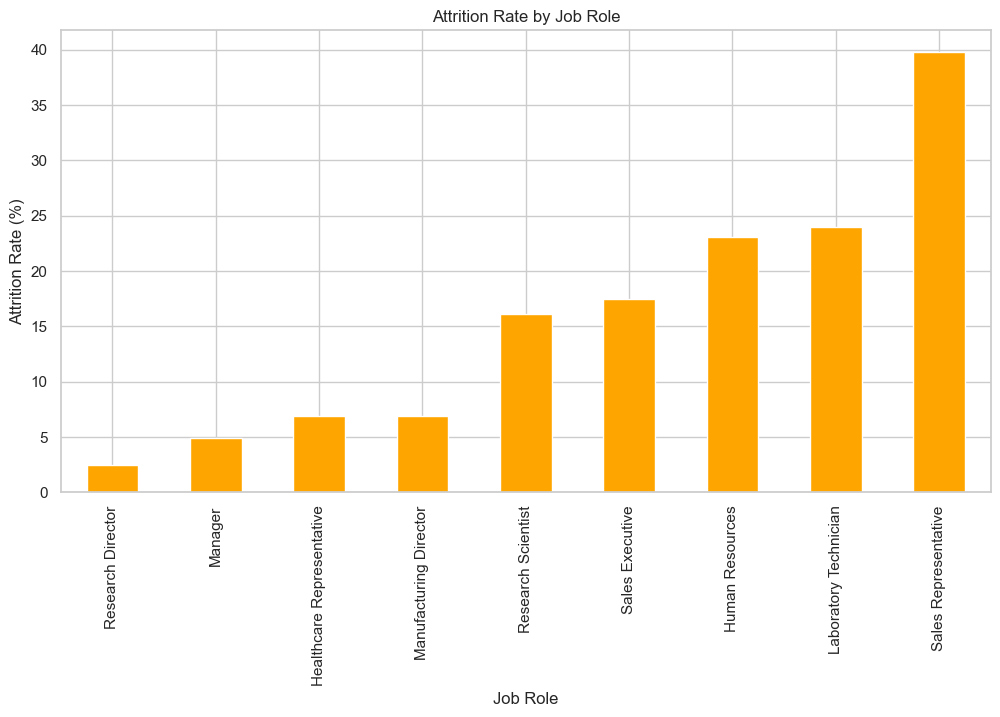

In [72]:
plt.figure(figsize=(12,6))

jobrole_attrition = pd.crosstab(df["JobRole"], df["Attrition"], normalize="index") * 100

jobrole_attrition[1].sort_values().plot(kind="bar", color="orange")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.savefig("charts/chart2_jobrole_attrition.png", dpi=300, bbox_inches="tight")
plt.show()

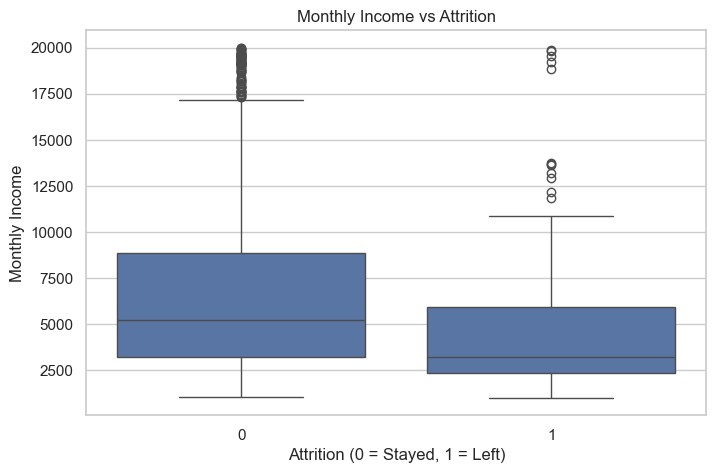

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")
plt.savefig("charts/chart4_worklife_balance.png", dpi=300, bbox_inches="tight")
plt.show()

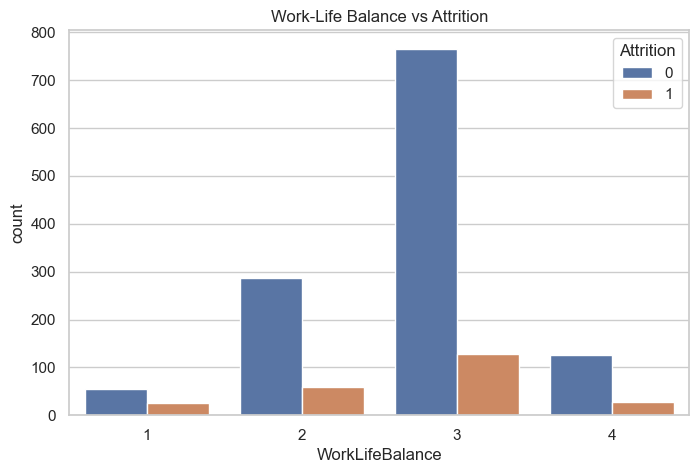

In [74]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="WorkLifeBalance",
    hue="Attrition",
    data=df
)

plt.title("Work-Life Balance vs Attrition")
plt.savefig("charts/chart5_years_at_company.png", dpi=300, bbox_inches="tight")
plt.show()

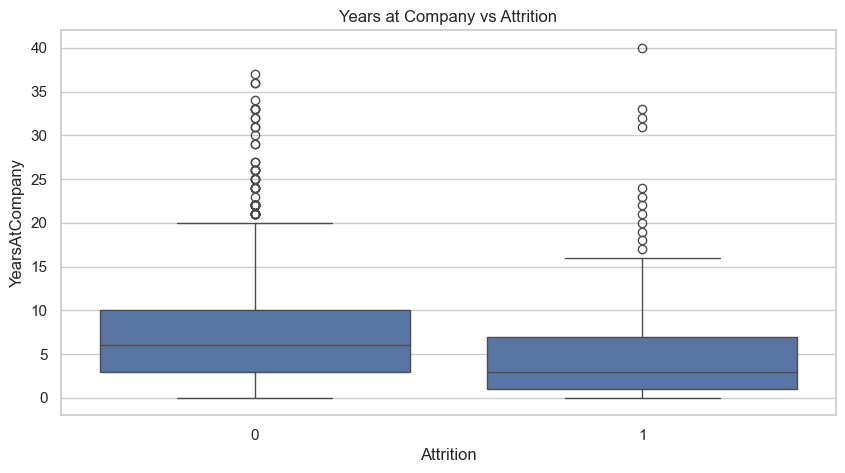

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=df
)

plt.title("Years at Company vs Attrition")
plt.savefig("charts/chart5_years_at_company.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import os 
print(os.path.isdir("charts"))

# Task 4: Model Building & Comparison

In this section, three machine learning classification models are trained and compared to predict employee attrition.

The models used are:

- Logistic Regression
- Random Forest Classifier
- Gradient Boosting Classifier

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [78]:
# Logistic Regression

lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [79]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [80]:
# Gradient Boosting

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:,1]

print("Gradient Boosting Model Trained Successfully!")

Gradient Boosting Model Trained Successfully!


In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [82]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[

        accuracy_score(y_test, lr_pred),

        accuracy_score(y_test, rf_pred),

        accuracy_score(y_test, gb_pred)

    ],

    "Precision":[

        precision_score(y_test, lr_pred),

        precision_score(y_test, rf_pred),

        precision_score(y_test, gb_pred)

    ],

    "Recall":[

        recall_score(y_test, lr_pred),

        recall_score(y_test, rf_pred),

        recall_score(y_test, gb_pred)

    ],

    "F1 Score":[

        f1_score(y_test, lr_pred),

        f1_score(y_test, rf_pred),

        f1_score(y_test, gb_pred)

    ],

    "ROC AUC":[

        roc_auc_score(y_test, lr_prob),

        roc_auc_score(y_test, rf_prob),

        roc_auc_score(y_test, gb_prob)

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.755102,0.356322,0.659574,0.462687,0.803515
1,Random Forest,0.840136,0.500000,0.085106,0.145455,0.768886
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.794125


In [83]:
comparison.to_csv("Model_Comparison.csv", index=False)

# Task 5: Model Evaluation

The performance of all three machine learning models is evaluated using Precision, Recall, F1-Score, ROC-AUC Score, and Confusion Matrix. The best-performing model is then selected based on these evaluation metrics.

In [84]:
from sklearn.metrics import classification_report

print("========== Logistic Regression ==========")
print(classification_report(y_test, lr_pred))

print("\n========== Random Forest ==========")
print(classification_report(y_test, rf_pred))

print("\n========== Gradient Boosting ==========")
print(classification_report(y_test, gb_pred))

========== Logistic Regression ==========
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294


========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294


========== Gradient Boosting ==========
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro

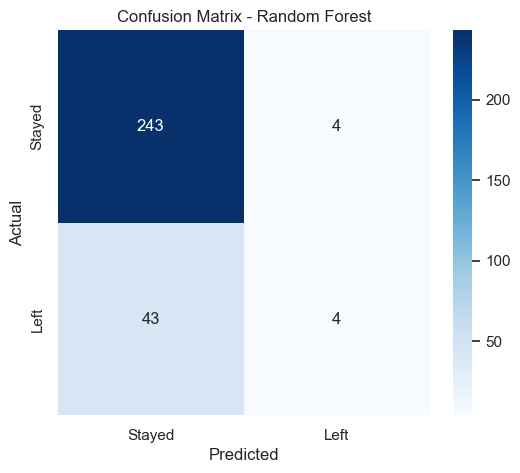

In [85]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed","Left"],
    yticklabels=["Stayed","Left"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "charts/chart6_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [86]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.074990
0,Age,0.064265
1,DailyRate,0.054629
16,TotalWorkingYears,0.051717
19,YearsAtCompany,0.050516
10,MonthlyRate,0.046254
5,HourlyRate,0.044628
43,OverTime_Yes,0.043875
22,YearsWithCurrManager,0.042047
2,DistanceFromHome,0.041556


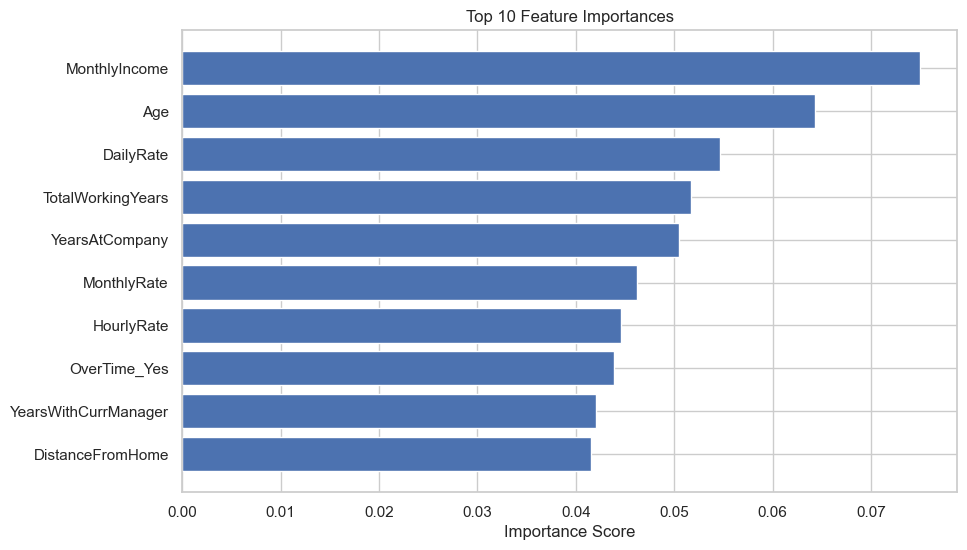

In [87]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances")

plt.xlabel("Importance Score")

plt.savefig(
    "charts/chart7_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 800x600 with 0 Axes>

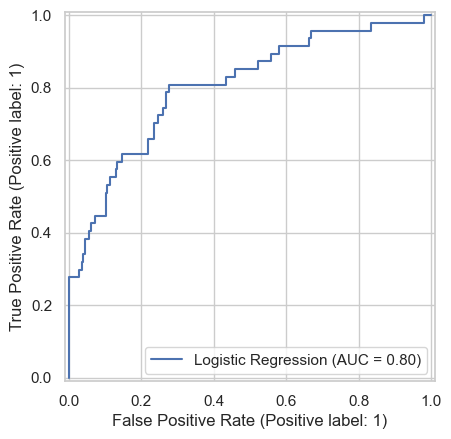

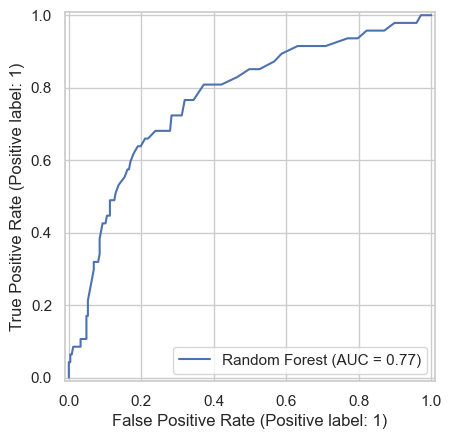

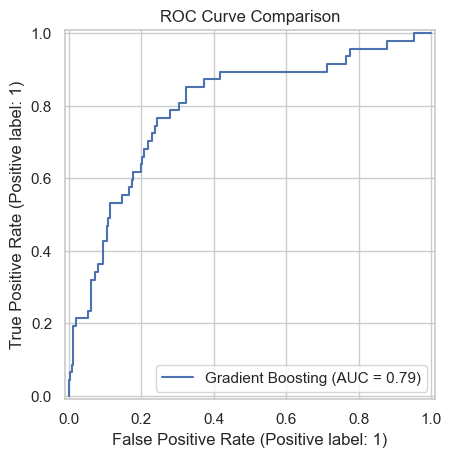

In [88]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    lr_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    gb_prob,
    name="Gradient Boosting"
)

plt.title("ROC Curve Comparison")

plt.savefig(
    "charts/chart8_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Best Performing Model

Based on the evaluation of all three machine learning models, **Logistic Regression** was selected as the best-performing model for this project.

Although the **Gradient Boosting** model achieved the highest overall accuracy (**85.03%**), the **Logistic Regression** model achieved the highest **Recall (65.96%)**, **F1-Score (46.27%)**, and **ROC-AUC Score (0.804)**.

For an employee attrition prediction problem, identifying employees who are likely to leave is more important than simply achieving the highest accuracy. A higher recall means the model successfully identifies more employees who are at risk of leaving, allowing the HR team to take preventive action.

Therefore, **Logistic Regression** provides the best balance between predictive performance and practical usefulness for HR decision-making in this project.

# HR Insights & Business Recommendations

## Key Findings

1. Employee attrition is influenced by multiple factors rather than salary alone. Work-life balance, years at the company, job satisfaction, and monthly income all contribute to whether an employee is likely to leave.

2. Employees with fewer years at the company showed a higher tendency to leave, indicating that employee retention efforts should focus on the early years of employment.

3. Logistic Regression achieved the best balance between identifying employees at risk of leaving and overall model performance, making it the most suitable model for this business problem.

## HR Recommendations

- HR should prioritize retention programs for employees who are in departments and job roles with higher attrition rates. Regular one-on-one discussions, career development opportunities, and mentoring programs can help improve employee retention.

- The company should strengthen work-life balance initiatives, recognize employee performance, and provide clear career growth opportunities. These measures can improve employee satisfaction and reduce voluntary attrition.

## Does Salary Alone Explain Attrition?

No. Although monthly income has an impact on employee attrition, the analysis shows that salary alone does not explain why employees leave. Factors such as job satisfaction, work-life balance, years at the company, and overall employee engagement also play an important role.

## Model Limitation

This machine learning model is trained using historical employee data and may not capture future organizational changes, personal circumstances, or external economic conditions. Therefore, the model should be used as a decision-support tool alongside human judgment rather than as the sole basis for HR decisions.